# Treemap

This section showcases the treemap. It contains examples of how to create treemaps using the [datachart.charts.Treemap](../../../references/charts/#datachart.charts.Treemap) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-treemap), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the treemaps are created using the `Treemap` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import Treemap

## Treemap Input Attributes

The `Treemap` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the records to tile. A treemap is a `{"data": [...]}` dict whose records are `{"label", "value"}` dicts; a record's `children` list groups it, up to four levels deep. A list of such dicts draws one treemap per subplot.

```python
Treemap(
    data={                                              # The records (or a list of such dicts, one treemap per subplot)
        "data": [
            {
                "label": str,                           # The drawn label of the tile or group
                "value": Union[int, float],             # The size of the tile; must be greater than 0
                "children": Optional[List[dict]],       # Records of the same shape, nesting up to four levels deep; a group then omits its value or carries their sum
                "emphasis": Optional[str],              # "background" mutes the tile or group, "highlight" strokes its border
            },
            ...
        ],
    },
    show_values=Optional[bool],                         # Whether to write each tile's value under its label
    value_format=Optional[str],                         # The format of the values, a VALUE_FORMAT constant or a format string
    show_legend=Optional[bool],                         # Whether to list the top-level records in a legend
    style={                                             # The style of the chart (optional; a list for multiple charts)
        "plot_treemap_edge_color":           Optional[str],    # The stroke color between tiles and around groups
        "plot_treemap_edge_width":           Optional[float],  # The stroke width between tiles (0.6 by default)
        "plot_treemap_group_edge_width":     Optional[float],  # The border width around a group (1 by default)
        "plot_treemap_group_pad":            Optional[float],  # The gap between groups as a fraction of the span (0.01 by default)
        "plot_treemap_level_shade":          Optional[float],  # How much lighter than its group a tile is, 0 to 1 (0.35 by default)
        "plot_treemap_level_font_scale":     Optional[float],  # The label font scale applied per nesting level (0.85 by default)
        "plot_treemap_min_fontsize":         Optional[float],  # The smallest font size a label shrinks to before it is dropped (6 by default)
        "plot_treemap_highlight_edge_width": Optional[float],  # The border width of a highlighted record (2 by default)
        "plot_treemap_label_halo_width":     Optional[float],  # The white halo behind the labels; 0 disables it (2 by default)
    },
    subtitle=Optional[str],                             # The chart subtitle (or list for multiple charts)
    title=Optional[str],                                # The chart title
    figsize=Optional[Tuple[float, float]],              # The figure size
    subplots=Optional[bool],                            # Whether to draw each chart in its own subplot
    max_cols=Optional[int],                             # The maximum number of subplot columns
    texts=Optional[Union[dict, List[dict]]],            # The text annotations
)
```

For more details, see the [datachart.charts.Treemap](../../../references/charts/#datachart.charts.Treemap) function.

## Basics

The examples in this guide share one dataset: the world's population in 2023 by continent and country, in millions, from the United Nations *World Population Prospects* estimates. Each continent lists its most populous countries and a "Rest of" bucket that makes the continent whole; the numbers live in the hidden cell below. Population is a textbook part-of-whole story: the world splits into continents, and each continent into countries — and a treemap shows both splits at once, with the area of every tile carrying its share.

In [2]:
# World population in 2023 by continent and country, millions (UN World Population
# Prospects estimates, rounded); the "Rest of" buckets complete each continent
WORLD = {
    "Asia": [
        ("India", 1429),
        ("China", 1426),
        ("Indonesia", 278),
        ("Pakistan", 240),
        ("Bangladesh", 173),
        ("Japan", 123),
        ("Rest of Asia", 1084),
    ],
    "Africa": [
        ("Nigeria", 224),
        ("Ethiopia", 127),
        ("Egypt", 113),
        ("DR Congo", 102),
        ("Rest of Africa", 895),
    ],
    "Europe": [
        ("Russia", 144),
        ("Germany", 83),
        ("UK", 68),
        ("France", 65),
        ("Rest of Europe", 382),
    ],
    "N. America": [("USA", 340), ("Mexico", 128), ("Rest of N. America", 132)],
    "S. America": [("Brazil", 216), ("Rest of S. America", 220)],
    "Oceania": [("Australia", 26), ("Rest of Oceania", 19)],
}

# one record per continent, its countries as children
world = {
    "data": [
        {
            "label": continent,
            "children": [{"label": c, "value": n} for c, n in countries],
        }
        for continent, countries in WORLD.items()
    ]
}

The data is one dict with a `data` list. Every record is a dict with a `label` and a `value` above zero; a record that carries `children` is a group, and its children are records of the same shape. Groups nest up to four levels deep, and a group either omits its `value` or carries the sum of its children — anything else raises a `ValueError`, as does a zero or negative value. The order of the records does not matter: every level is sorted largest first before it is tiled.

!!! note "Four levels of nesting"
    A treemap nests its records four levels deep: the `data` list is the first level, and a record at the fourth cannot carry `children` of its own. The cap is a readability limit — every level takes a header band and a lighter tint from its parent, and at the default figure sizes a fifth level has no room left for its labels. For a deeper hierarchy, fold the lowest levels into "Rest of" buckets, or draw a subtree as its own treemap with [subplots](#subplots).

In [3]:
world["data"][0]["label"], world["data"][0]["children"][:3]

('Asia',
 [{'label': 'India', 'value': 1429},
  {'label': 'China', 'value': 1426},
  {'label': 'Indonesia', 'value': 278}])

**Basic example.** Only the `data` argument is required to draw the treemap. Each continent is a bordered box with a header band, its countries are tiles in a lighter tint of the continent's color, and the largest tile of every level sits top-left. The tiles are squarified in the drawn aspect of the axes, so they stay near square whatever the figure size. A label that does not fit its tile wraps, then shrinks, then is dropped; a group too short for its band goes unlabelled, and the [legend](#legend) is what names it.

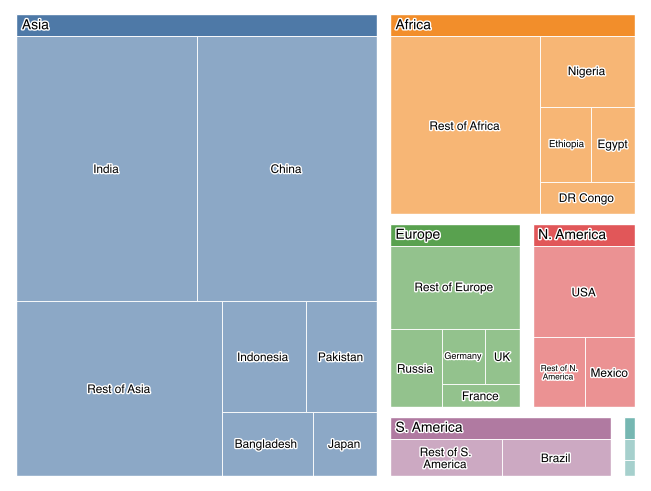

In [4]:
Treemap(
    # add the data to the chart
    data=world
).show()

## Customizing the Treemap

Every customization is either a keyword argument of `Treemap` or a `plot_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title                                 | `title`                                                                 | [Title and figure size](#title-and-figure-size) |
| resize the figure                           | `figsize`                                                               | [Title and figure size](#title-and-figure-size) |
| tile one level without groups               | records without `children`                                              | [Flat data](#flat-data) |
| nest groups inside groups                   | `children` on a child record, up to four levels                         | [Nested groups](#nested-groups) |
| write the values on the tiles               | `show_values`, `value_format`                                           | [Tile values](#tile-values) |
| mute or outline a tile or a group           | `"emphasis"` on the record                                              | [Emphasis](#emphasis) |
| name the groups in a legend                 | `show_legend`                                                           | [Legend](#legend) |
| widen the gap around groups                 | `style={"plot_treemap_group_pad": ...}`                                 | [Tile style](#tile-style) |
| change the tint of the tiles in a group     | `style={"plot_treemap_level_shade": ...}`                               | [Tile style](#tile-style) |
| change the strokes or the label sizes       | `style={"plot_treemap_edge_width": ..., "plot_treemap_min_fontsize": ...}` | [Tile style](#tile-style) |
| drop the halo behind the labels             | `style={"plot_treemap_label_halo_width": 0}`                            | [Tile style](#tile-style) |
| annotate a point of the chart               | `texts`                                                                 | [Text annotations](#text-annotations) |
| draw several treemaps side by side          | `subplots`                                                              | [Subplots](#subplots) |
| arrange a treemap next to other charts      | `Grid`                                                                  | [Composing treemaps](#composing-treemaps) |

### Title and figure size

To add the chart title, add the `title` attribute. A treemap has no axes, so there are no axis labels to set. To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains predefined figure sizes. The tiles are laid out in the aspect of the figure you choose, so a wide figure and a square one both keep the tiles near square.

In [5]:
from datachart.constants import FIG_SIZE

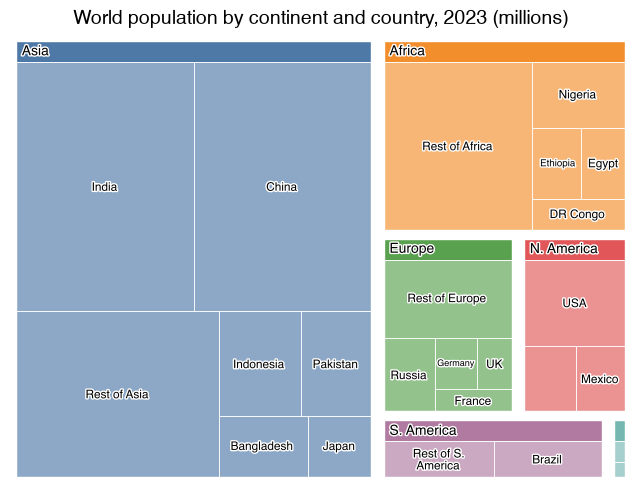

In [6]:
Treemap(
    data=world,
    # add the title
    title="World population by continent and country, 2023 (millions)",
    # add to determine the figure size
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Flat data

Records without `children` are tiles of their own: each takes the next palette color, and there are no bands or borders. The example tiles the continents by their totals, which is the top level of the nested chart on its own.

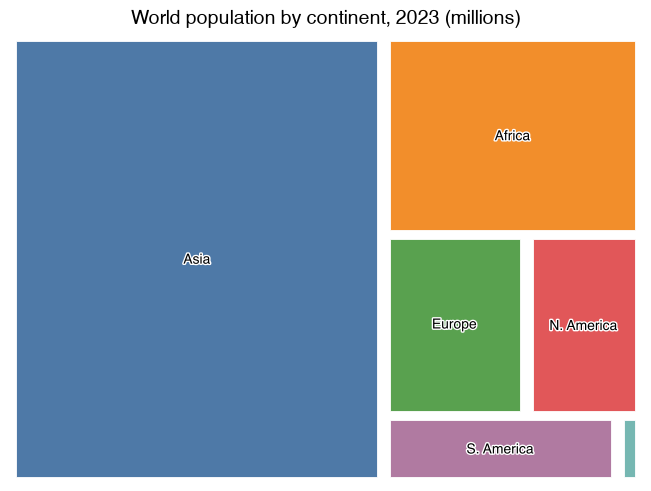

In [7]:
continents = {
    "data": [
        {"label": continent, "value": sum(n for _, n in countries)}
        for continent, countries in WORLD.items()
    ]
}

Treemap(
    data=continents,
    title="World population by continent, 2023 (millions)",
).show()

### Nested groups

A child record may carry `children` of its own, up to four levels deep, and every level follows the same rules as the top one: a group is a bordered box with a header band, its children one tint lighter, and the largest sits top-left. A nested group's band shrinks its font when the box is short — scratch in the example — and a group too short even for that draws its border only, like Mail; either way the [legend](#legend) still names the top-level groups alone. Every group insets its children by half of `plot_treemap_group_pad`, the same gap that sets the top-level records off from the edge, so a nested box sits visibly inside its parent; the children themselves meet at the stroke. The example is a home folder four levels deep, in gigabytes: the nested dicts are turned into records by a small recursive helper.

In [ ]:
# a home folder: a dict is a folder, a number a file size in GB
HOME = {
    "Projects": {
        "datachart": {"docs": 14, "src": 6, ".venv": 22, "test": 3},
        "thesis": {"figures": 18, "chapters": 4, "data": 31},
        "scratch": {"notes": 3, "tmp": 6},
    },
    "Media": {
        "Photos": {"2024": 38, "2025": 52, "raw": 61},
        "Videos": 47,
        "Music": 12,
    },
    "Library": {"Caches": 28, "Mail": {"Inbox": 3, "Archive": 2}, "Fonts": 2},
    "Downloads": 24,
    "Desktop": 5,
}


def records(tree):
    """A folder's records: a number is a tile, a dict a group of its own."""
    return [
        {"label": name, "value": size}
        if not isinstance(size, dict)
        else {"label": name, "children": records(size)}
        for name, size in tree.items()
    ]


Treemap(
    data={"data": records(HOME)},
    title="Home folder by size (GB)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Tile values

To write each tile's value under its label, add the `show_values` attribute. The `value_format` attribute formats the values: use one of the [datachart.constants.VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constants or any `"{x:.1f}"`, `"{:.1f}%"`, or `"%g"` style string. The values follow the labels' fitting rules; when a tile has room for its label but not for both, the value is dropped first.

In [8]:
from datachart.constants import VALUE_FORMAT

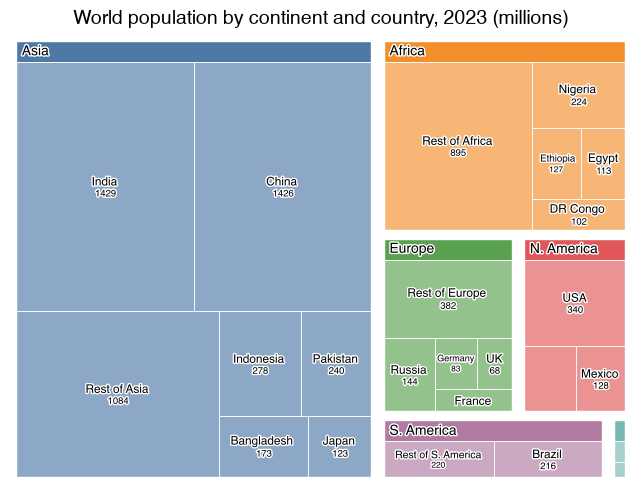

In [9]:
Treemap(
    data=world,
    # write the population on the tiles
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    title="World population by continent and country, 2023 (millions)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Emphasis

Emphasis is set per record with the `emphasis` key, using the [datachart.constants.EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) roles. `background` mutes a tile or a whole group into the theme's muted color; `highlight` strokes the border of a tile or a group in the text color. A child's role overrides its group's, so a highlighted country stays vivid inside a muted continent. Roles are explicit: highlighting one record does not mute the others, and the `emphasis` argument of the function itself is not supported — pass the roles on the records.

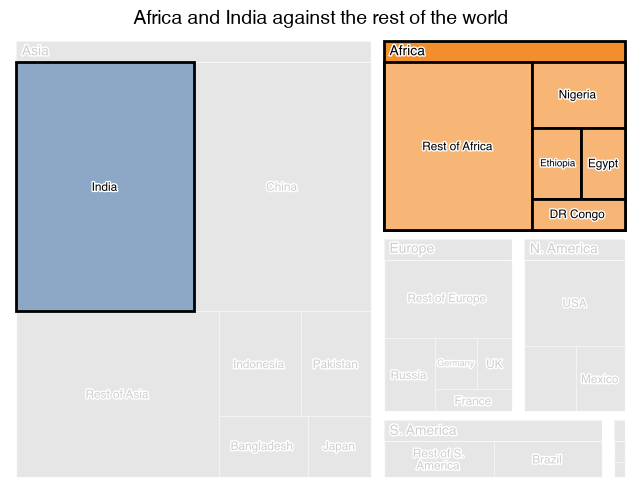

In [10]:
from datachart.constants import EMPHASIS

emphasized = {
    "data": [
        {
            "label": continent,
            # mute every continent but Africa
            "emphasis": EMPHASIS.HIGHLIGHT if continent == "Africa" else EMPHASIS.BACKGROUND,
            "children": [
                {
                    "label": c,
                    "value": n,
                    # India stays vivid inside a muted Asia
                    **({"emphasis": EMPHASIS.HIGHLIGHT} if c == "India" else {}),
                }
                for c, n in countries
            ],
        }
        for continent, countries in WORLD.items()
    ]
}

Treemap(
    data=emphasized,
    title="Africa and India against the rest of the world",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Legend

To list the top-level records in a legend, add the `show_legend` attribute. The legend sits beside the tiles, since they fill the axes, and names the groups whose box is too short for a header band — Oceania in the example.

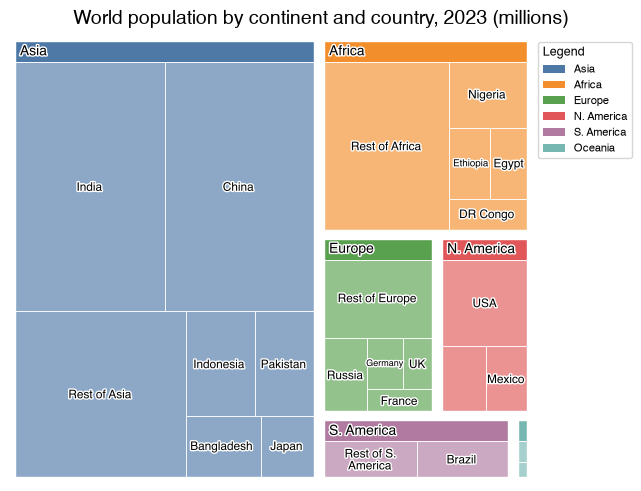

In [11]:
Treemap(
    data=world,
    # name the continents beside the chart
    show_legend=True,
    title="World population by continent and country, 2023 (millions)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Tile style

To change the tile style, add the `style` attribute with the corresponding attributes. The supported attributes are shown in the [datachart.typings.TreemapStyleAttrs](../../../references/typings/#datachart.typings.TreemapStyleAttrs) typing. `plot_treemap_group_pad` is the gap between the top-level records as a fraction of the drawing, and half of it is the gutter between a group's border and its children at every level; the children themselves are separated by a stroke only, drawn in `plot_treemap_edge_color` at `plot_treemap_edge_width`; `plot_treemap_group_edge_width` draws the border around a group in the same color. `plot_treemap_level_shade` says how much lighter than its parent each level is, from `0` (the group color) to `1` (white), applied once more per level. Tile labels shrink by `plot_treemap_level_font_scale` per nesting level and down to `plot_treemap_min_fontsize` before they are dropped; every label sits behind a white halo of `plot_treemap_label_halo_width`, and `0` drops it.

The example widens the gap around the continents and their countries, keeps the countries closer to the continent color, and drops the halo.

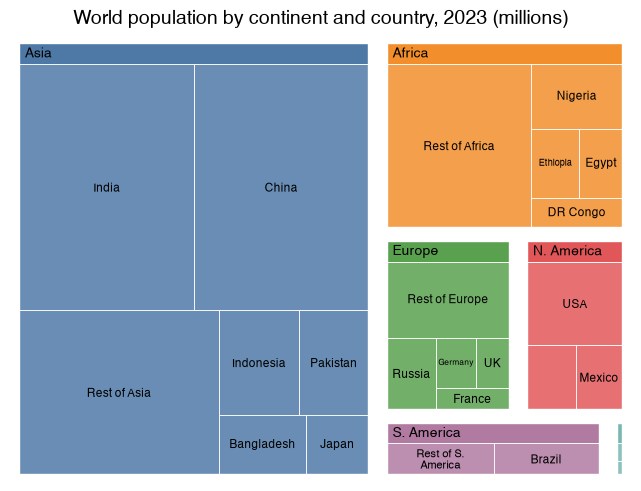

In [12]:
Treemap(
    data=world,
    style={
        # a wider gap around the continents
        "plot_treemap_group_pad": 0.03,
        # the countries close to the continent color
        "plot_treemap_level_shade": 0.15,
        # no halo behind the labels
        "plot_treemap_label_halo_width": 0,
    },
    title="World population by continent and country, 2023 (millions)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Text annotations

To place text on the chart, add the `texts` attribute with the [datachart.typings.TextAttrs](../../../references/typings/#datachart.typings.TextAttrs) records. The tiling spans `0`–`1` in both directions, so `x` and `y` are fractions of the drawing; the [Text Annotations](../utility/annotations.ipynb) guide covers the connector and box options. The example points out how much of the world lives in Asia.

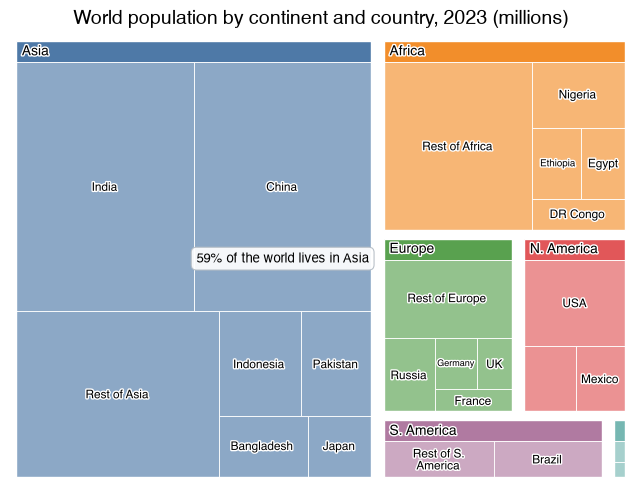

In [13]:
asia = sum(n for _, n in WORLD["Asia"])
total = sum(n for countries in WORLD.values() for _, n in countries)

Treemap(
    data=world,
    texts={
        "x": 0.3,
        "y": 0.5,
        "text": f"{100 * asia / total:.0f}% of the world lives in Asia",
        "ha": "center",
    },
    title="World population by continent and country, 2023 (millions)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Multiple Treemaps

### Subplots

A list of treemaps draws each in its own subplot; there is no overlay of two treemaps on one axes, so `subplots` is implied. The `subtitle` becomes the subplot title and the `title` is positioned to be global for all charts. The `max_cols` attribute limits the number of columns. The example draws the two largest continents on their own, so their countries get the whole tiling each.

In [14]:
by_continent = [
    {"data": [{"label": c, "value": n} for c, n in WORLD[continent]]}
    for continent in ("Asia", "Africa")
]

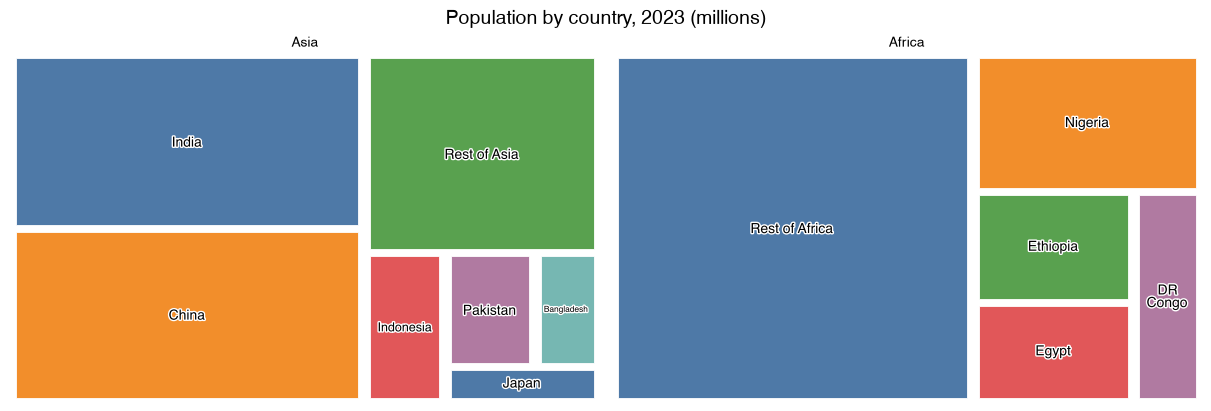

In [15]:
Treemap(
    # one treemap per continent
    data=by_continent,
    subtitle=["Asia", "Africa"],
    max_cols=2,
    title="Population by country, 2023 (millions)",
    figsize=(12, 4),
).show()

### Composing Treemaps

A treemap owns its axes: there is no shared coordinate space to overlay other charts on, so [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) rejects a treemap figure. [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges it next to other figures as an ordinary cell, and the tiles are laid out again in the cell's own aspect. The grid pairs the treemap with a [datachart.charts.BarChart](../../../references/charts/#datachart.charts.BarChart) of the continent totals.

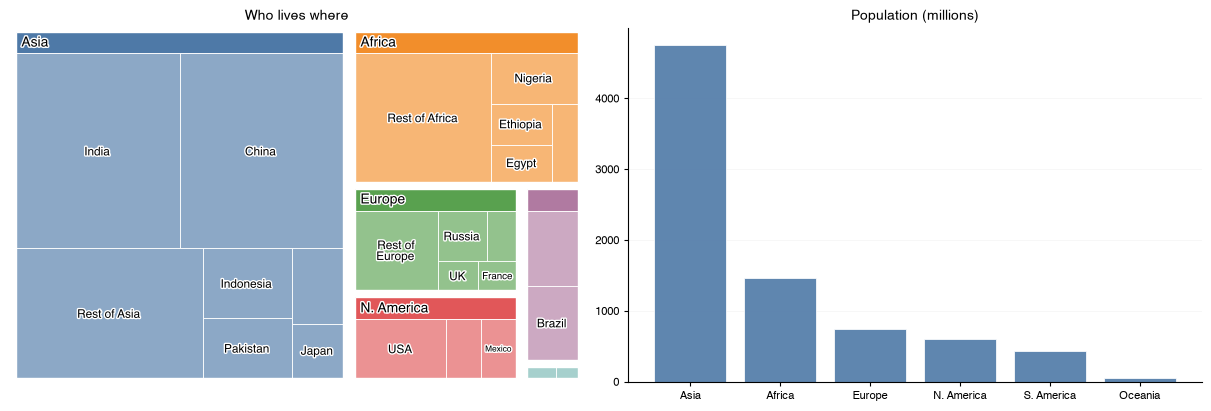

In [16]:
from datachart.charts import BarChart
from datachart.utils import Grid

tiles = Treemap(data=world, title="Who lives where")
totals = BarChart(
    data=[{"label": r["label"], "y": r["value"]} for r in continents["data"]],
    title="Population (millions)",
)
Grid([[tiles, totals]], figsize=(12, 4)).show()

### Themes

A theme sets the palette, the tile strokes and the fonts of every chart at once; see the [Theme Gallery](../../styling/theme-gallery.ipynb) for the whole suite under each. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) from the [datachart.constants.THEME](../../../references/constants/#datachart.constants.THEME) constant, and reset the configuration afterwards so the following charts draw in the default again.

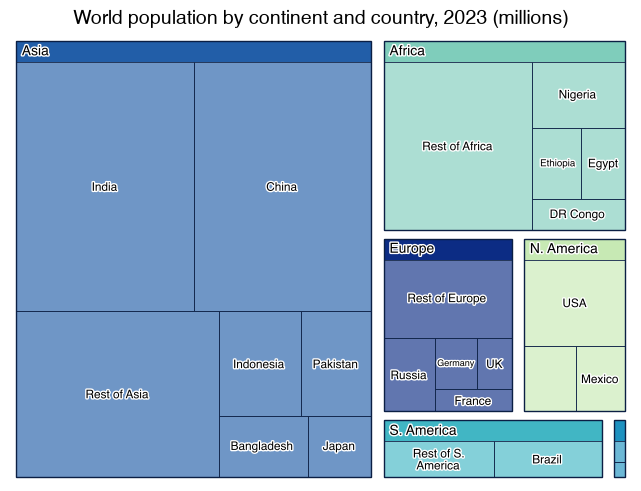

In [17]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.INK)
figure = Treemap(
    data=world,
    title="World population by continent and country, 2023 (millions)",
    figsize=FIG_SIZE.FULL_MEDIUM,
)
config.reset_config()
figure.show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [18]:
from datachart.utils import save_figure

figure = Treemap(
    data=world,
    title="World population by continent and country, 2023 (millions)",
)
save_figure(figure, "./fig_treemap.png", dpi=300)

The figure should be saved in the current working directory.

## Real-World Examples

The following examples put the features above to work. Each one states what it shows; any derived quantity is computed in the code, and the data is illustrative.

### Example 1: Disk Usage by Folder (Nested Groups, Values, and a Highlight)

A home directory, sized by folder and sub-folder in gigabytes, the way a disk-usage tool shows it. Every top-level folder is a group and its sub-folders the tiles; the values are written on the tiles, and the one folder worth cleaning up is highlighted. The `"Other"` buckets keep every group whole.

In [19]:
DISK = {
    "Videos": [("Raw footage", 310), ("Exports", 95), ("Other", 20)],
    "Photos": [("2024", 120), ("2023", 96), ("Archive", 64)],
    "Projects": [("datasets", 140), ("node_modules", 58), ("Other", 32)],
    "Library": [("Caches", 74), ("Mail", 22), ("Other", 18)],
    "Downloads": [("Installers", 41), ("Other", 27)],
    "Music": [("Lossless", 45), ("Other", 9)],
}

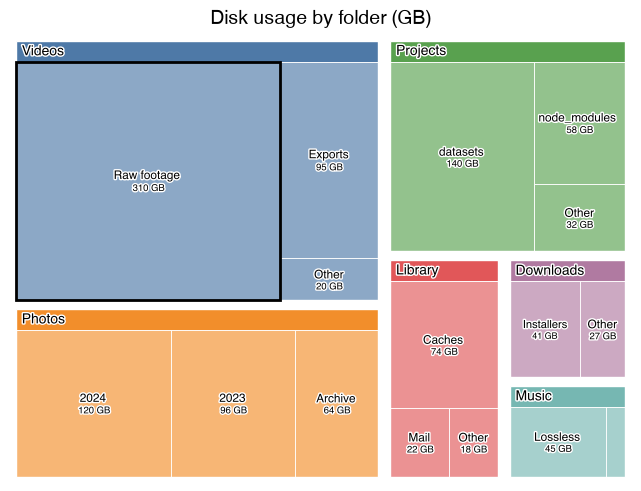

In [20]:
disk = {
    "data": [
        {
            "label": folder,
            "children": [
                {
                    "label": sub,
                    "value": gb,
                    # the raw footage is where the space goes
                    **({"emphasis": EMPHASIS.HIGHLIGHT} if sub == "Raw footage" else {}),
                }
                for sub, gb in subs
            ],
        }
        for folder, subs in DISK.items()
    ]
}

Treemap(
    data=disk,
    show_values=True,
    value_format="{x} GB",
    title="Disk usage by folder (GB)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 2: A Department Budget (Muted Fixed Costs and a Legend)

A yearly budget split by department and then by line, in thousands. The fixed costs — rent and insurance — are what the team cannot change, so they are muted into the background, and the legend names every department including the ones too small for a band.

In [21]:
BUDGET = {
    "Engineering": [("Salaries", 1450), ("Cloud", 380), ("Tooling", 90), ("Training", 45)],
    "Sales": [("Salaries", 620), ("Travel", 140), ("Events", 85)],
    "Marketing": [("Campaigns", 310), ("Salaries", 260), ("Agencies", 120)],
    "Fixed costs": [("Rent", 420), ("Insurance", 110)],
    "Support": [("Salaries", 280), ("Software", 40)],
    "Legal": [("Counsel", 95), ("Filings", 25)],
}

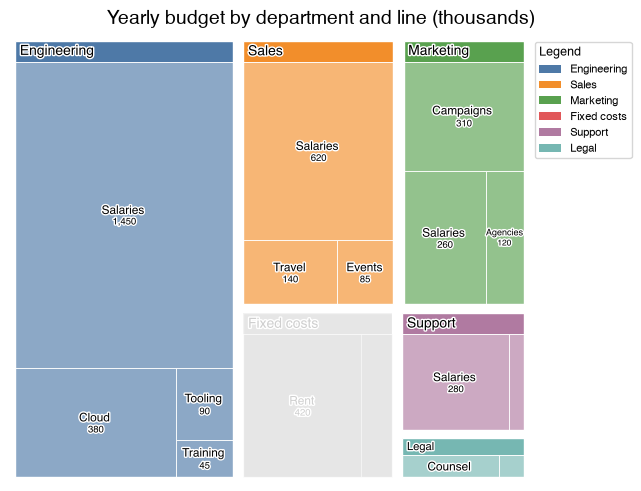

In [22]:
budget = {
    "data": [
        {
            "label": department,
            # the fixed costs are context, not a lever
            **({"emphasis": EMPHASIS.BACKGROUND} if department == "Fixed costs" else {}),
            "children": [{"label": line, "value": k} for line, k in lines],
        }
        for department, lines in BUDGET.items()
    ]
}

Treemap(
    data=budget,
    show_values=True,
    value_format=VALUE_FORMAT.THOUSANDS,
    show_legend=True,
    title="Yearly budget by department and line (thousands)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()